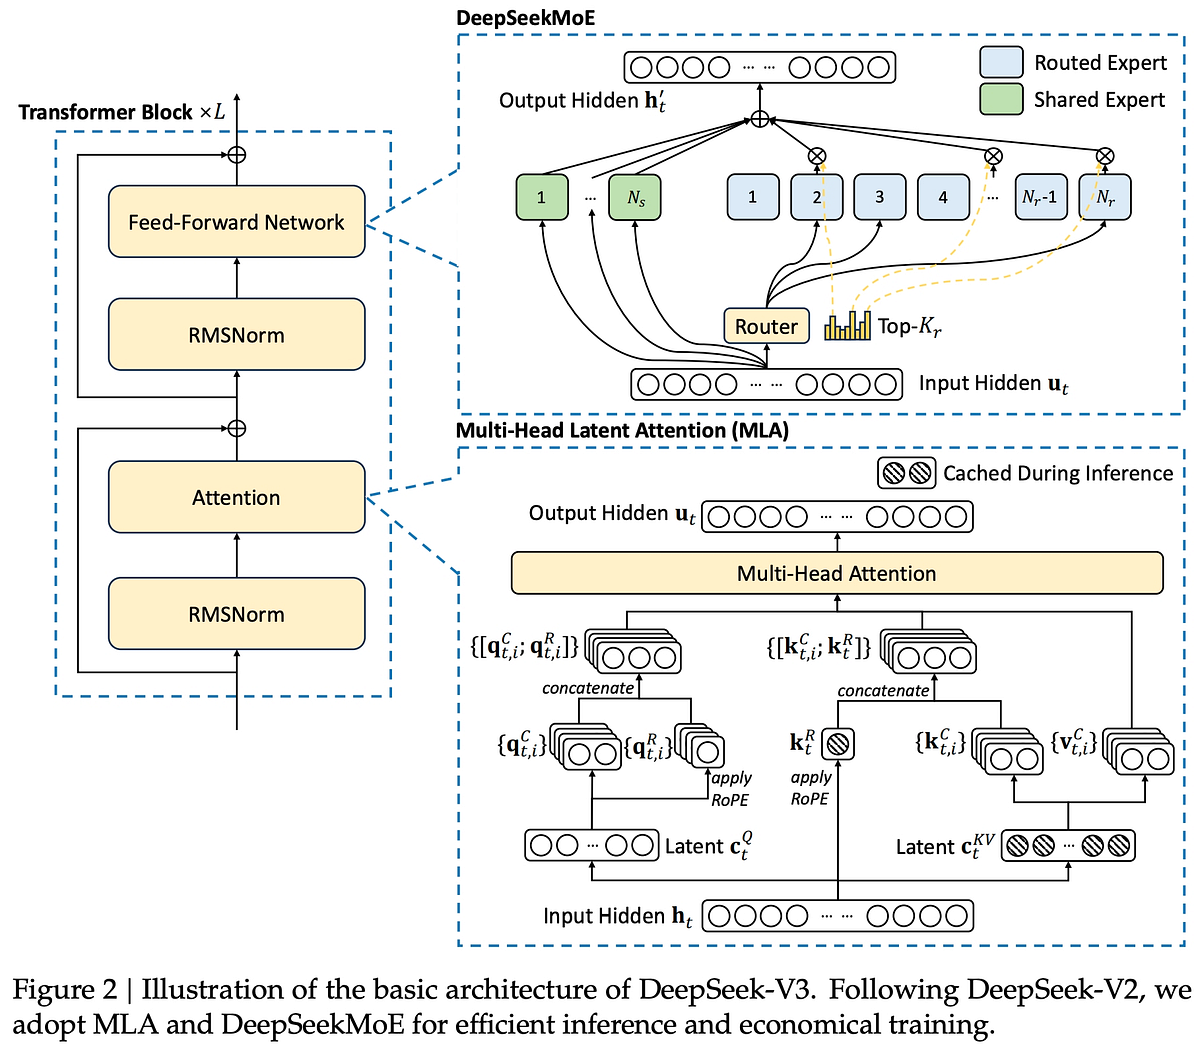


In [ ]:
class Gate(nn.Module):
    def __init__(self):
        self.topk = args.n_activated_experts
        self.n_groups = args.n_expert_groups
        self.topk_groups = args.n_limited_groups
        self.weight = nn.Parameter(torch.empty(args.n_routed_experts, args.dim))
        self.bias = nn.Parameter(torch.empty(args.n_routed_experts))

    def forward(self, x):
        scores = linear(x, self.weight)  # 计算每个专家的得分，以便选取topk
        scores = scores + self.bias
        scores = scores.sigmoid()
        scores = scores.view(x.size(0), self.n_groups, -1)  # 将scores按顺序进行分8组
        group_scores = scores.topk(2, dim=-1)[0].sum(dim=-1)  # 每组选取最大的两个得分，求和
        indices = group_scores.topk(self.topk_groups, dim=-1)[1]  # 选择得分最高的4个组
        # 将未选择的组的所有值屏蔽掉
        mask = torch.zeros_like(scores[..., 0]).scatter_(1, indices, True)
        scores = (scores * mask.unsqueeze(-1)).flatten(1)
        indices = torch.topk(scores, self.topk, dim=-1)[1]  # 从留下的值中选择topk
        weights = original_scores.gather(1, indices)  # 获得对应索引的权重

        return weights, indices

#### MOE主要是通过将FFN层变为多专家，每个专家有自己擅长的“领域”，输入的token会分配到不同的专家处进行处理，实现不增加计算量但增大模型规模的目的。
#### 这个deepseek的MOE分为共享专家（每个token都要处理）和路由专家。671B的模型有256个路由专家，每个token用8个路由专家
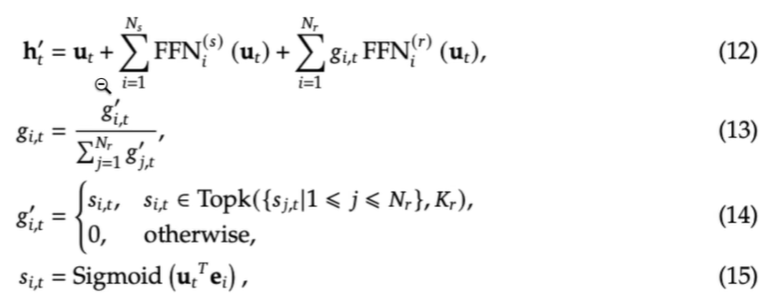

#### 相比V2，V3采用了sigmoid作为计算路由的函数，而不是softmax。同时负载均衡是通过加一个偏置项实现的，常规是使用loss来限制。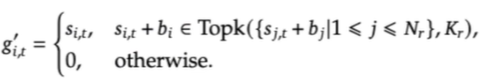

#### 具体流程：
每一个输入（FFN层）都会进入共享专家层，然后对于路由专家计算一个得分（用一个可训练的linear层），将256个专家分成8组，每组取前两名的得分和作为组得分，然后选出前四组，最后从这四组中选8个路由专家。之后把所有专家的结果进行一个累加，得到最终的FFN输出。

每个专家就是一个swiGLU的逐位置前馈层。负载均衡通过self.bias来控制，被用的多的降低scores

## MLA
分组多头注意力等会损失性能，MLA就是将KV cache进行低秩压缩降低存储占用空间。实际计算的时候先还原再算MHA即可

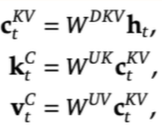

在实际神经网络训练过程中，会直接学到这两个上采样矩阵。K的上采样矩阵融合到Q的上采样矩阵中，V的上采样矩阵融合到输出层的矩阵中，减少计算量。

由于引入repo会导致无法矩阵融合，所以模型设计为将下采样后的Q和初始的K分一部分出去做repo，之后再直接合并起来。

## MTP

多token预测只在训练的时候预测。即计算loss。正常使用推理时还是只是预测下一个词。

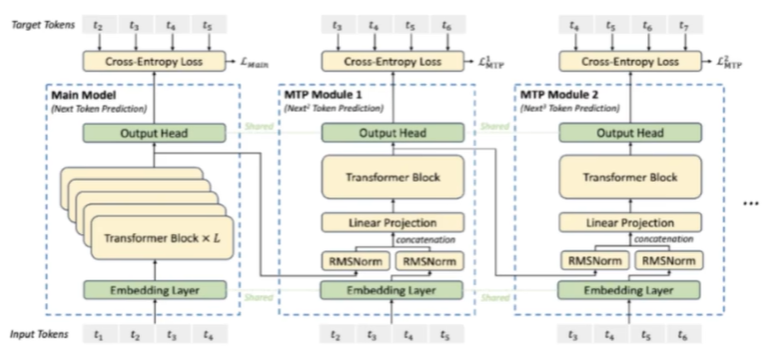